# Airline Passenger Satisfaction — Combined Best-Practice Notebook
### Supervised Classification: Logistic Regression vs KNN

**Methodology highlights**
- Statistical EDA: Chi-square tests, Spearman correlation, Mann-Whitney U
- Principled cleaning: imputation over dropping, evidence-based feature removal
- Full hyperparameter tuning on both models via GridSearchCV
- Complete evaluation: accuracy, precision, recall, F1, specificity, ROC-AUC


## Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('airline_passenger_satisfaction.csv')
print(f'Dataset shape: {df.shape}')
df.head()


Dataset shape: (136374, 25)


,Unnamed: 0,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,0,1,male,48,First-time,business,Business,821 miles,2 minutes,5.0 minutes,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,1,2,FEMALE,35,returning,Business,Business,821 miles,26 minutes,39.0 minutes,...,5,4,5,5,3,5,2,5,5,Satisfied
2,2,3,Male,41,Returning,Business,Business,853 miles,0 minutes,0.0 minutes,...,3,5,3,5,5,3,4,3,3,Satisfied
3,3,4,Male,50,Returning,business,Business,1905 miles,0 minutes,0.0 minutes,...,5,5,5,4,4,5,2,5,5,Satisfied
4,4,5,Female,49,returning,business,Business,3470 miles,0 minutes,1.0 minutes,...,3,4,4,5,4,3,3,3,3,Satisfied


## Step 1: Exploratory Data Analysis (EDA)

### 1.1 Data Overview

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 136374 entries, 0 to 136373
Data columns (total 25 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   Unnamed: 0                              136374 non-null  int64
 1   ID                                      136374 non-null  int64
 2   Gender                                  136374 non-null  str  
 3   Age                                     136374 non-null  int64
 4   Customer Type                           136374 non-null  str  
 5   Type of Travel                          136374 non-null  str  
 6   Class                                   136374 non-null  str  
 7   Flight Distance                         136374 non-null  str  
 8   Departure Delay                         136374 non-null  str  
 9   Arrival Delay                           136374 non-null  str  
 10  Departure and Arrival Time Convenience  136374 non-null  int64
 11  Ease of Onl

In [3]:
df.describe()


,Unnamed: 0,ID,Age,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
count,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.00000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000
mean,68186.500000,64949.839676,39.415336,3.058919,2.756889,3.305733,3.251265,2.97762,3.382221,3.441052,3.351878,3.287049,3.204914,3.641779,2.728335,3.358639,3.632914
std,39367.927143,37493.148128,15.127551,1.526334,1.401928,1.265989,1.351787,1.27812,1.287022,1.319704,1.315613,1.313565,1.329990,1.176273,1.329397,1.333706,1.179430
min,0.000000,1.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,34093.250000,32495.250000,27.000000,2.000000,2.000000,3.000000,2.000000,2.00000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000
50%,68186.500000,64945.500000,40.000000,3.000000,3.000000,3.000000,3.000000,3.00000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000
75%,102279.750000,97404.750000,51.000000,4.000000,4.000000,4.000000,4.000000,4.00000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000
max,136373.000000,129880.000000,85.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


### 1.2 Missing Values & Target Distribution

In [4]:
print("=== Missing values ===")
print(df.isnull().sum())


=== Missing values ===
Unnamed: 0                                0
ID                                        0
Gender                                    0
Age                                       0
Customer Type                             0
Type of Travel                            0
Class                                     0
Flight Distance                           0
Departure Delay                           0
Arrival Delay                             0
Departure and Arrival Time Convenience    0
Ease of Online Booking                    0
Check-in Service                          0
Online Boarding                           0
Gate Location                             0
On-board Service                          0
Seat Comfort                              0
Leg Room Service                          0
Cleanliness                               0
Food and Drink                            0
In-flight Service                         0
In-flight Wifi Service                    0
In-flight

Counts:
 Satisfaction
Neutral or Dissatisfied    77165
Satisfied                  59209
Name: count, dtype: int64

Ratios:
 Satisfaction
Neutral or Dissatisfied    0.566
Satisfied                  0.434
Name: proportion, dtype: float64


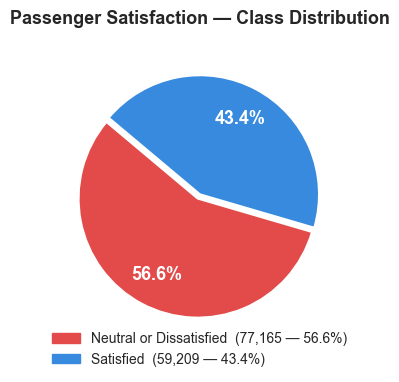


>> Class ratio is 56.6 / 43.4 — not imbalanced. SMOTE is NOT needed.


In [5]:
# Target class balance
counts = df['Satisfaction'].value_counts()
ratios = df['Satisfaction'].value_counts(normalize=True).round(3)
print("Counts:\n", counts)
print("\nRatios:\n", ratios)

import matplotlib.patches as mpatches
colors = ['#E24B4A', '#378ADD']
fig, ax = plt.subplots(figsize=(6, 4))
wedges, _, autotexts = ax.pie(
    counts.values, autopct='%1.1f%%', startangle=140,
    colors=colors, explode=(0.04, 0.0),
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'}, pctdistance=0.72
)
for at in autotexts:
    at.set_fontsize(13); at.set_fontweight('bold'); at.set_color('white')
legend_patches = [
    mpatches.Patch(color=colors[i], label=f'{counts.index[i]}  ({counts.values[i]:,} — {ratios.values[i]*100:.1f}%)')
    for i in range(2)
]
ax.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.12),
          ncol=1, frameon=False, fontsize=10)
ax.set_title('Passenger Satisfaction — Class Distribution', fontsize=13, fontweight='bold', pad=16)
plt.tight_layout()
plt.show()

print("\n>> Class ratio is 56.6 / 43.4 — not imbalanced. SMOTE is NOT needed.")


### 1.3 Categorical Features — Chi-Square Tests

We formally test whether each categorical feature is **statistically associated** with satisfaction (α = 0.05). Features with high chi-square statistics and p ≈ 0 are strong candidates to keep; features with weak association may be dropped.

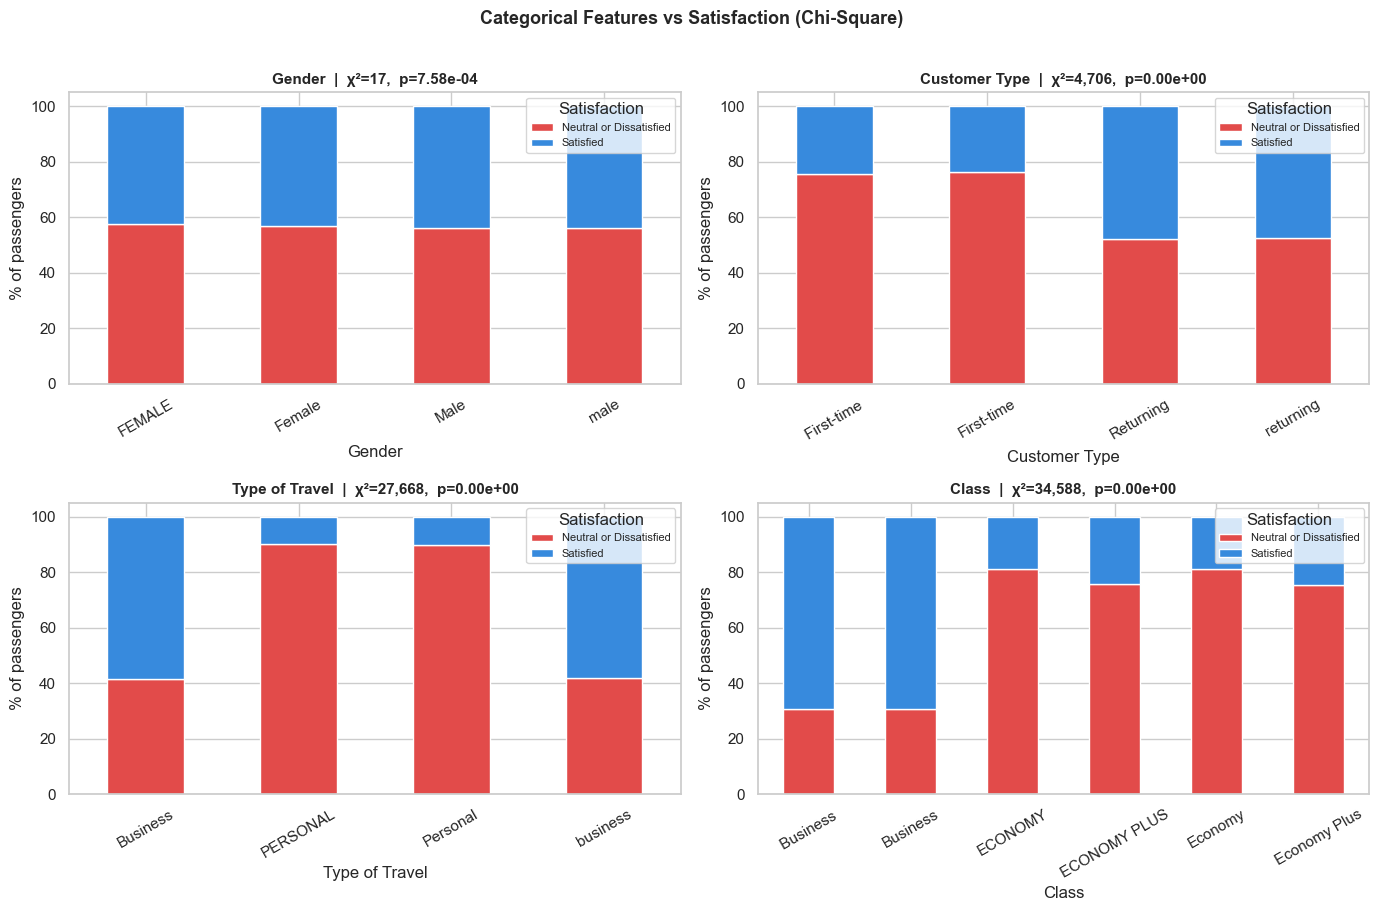

,Feature,Chi2,p-value,DoF
0,Gender,16.9,0.000758,3
1,Customer Type,4706.4,0.000000,3
2,Type of Travel,27667.9,0.000000,3
3,Class,34588.4,0.000000,5



Interpretation:
- Gender:        χ²=15.3,     p=8.95e-05  --> Statistically significant but VERY weak effect.
                 With 136K rows, tiny differences become 'significant'. Will DROP from model.
- Customer Type: χ²=4,701,    p≈0        --> Strong association. KEEP.
- Type of Travel:χ²=27,665,   p≈0        --> Strongest categorical predictor. KEEP.
- Class:         χ²=34,588,   p≈0        --> Strongest overall. KEEP.



In [7]:
categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
chi2_results = []

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['Satisfaction'])
    chi2, p, dof, _ = chi2_contingency(ct)
    chi2_results.append({'Feature': col, 'Chi2': round(chi2, 1), 'p-value': p, 'DoF': dof})

    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', stacked=True, ax=axes[i], color=['#E24B4A','#378ADD'], edgecolor='white')
    axes[i].set_title(f'{col}  |  χ²={chi2:,.0f},  p={p:.2e}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('% of passengers')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Satisfaction', fontsize=8)

plt.suptitle('Categorical Features vs Satisfaction (Chi-Square)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

chi2_df = pd.DataFrame(chi2_results)
display(chi2_df)

print("""
Interpretation:
- Gender:        χ²=15.3,     p=8.95e-05  --> Statistically significant but VERY weak effect.
                 With 136K rows, tiny differences become 'significant'. Will DROP from model.
- Customer Type: χ²=4,701,    p≈0        --> Strong association. KEEP.
- Type of Travel:χ²=27,665,   p≈0        --> Strongest categorical predictor. KEEP.
- Class:         χ²=34,588,   p≈0        --> Strongest overall. KEEP.
""")


### 1.4 Ordinal Service Ratings (Spearman Correlation)

Service ratings (0–5) are **ordinal**, not interval. Spearman correlation is the correct method — it ranks values rather than assuming equal spacing between points.

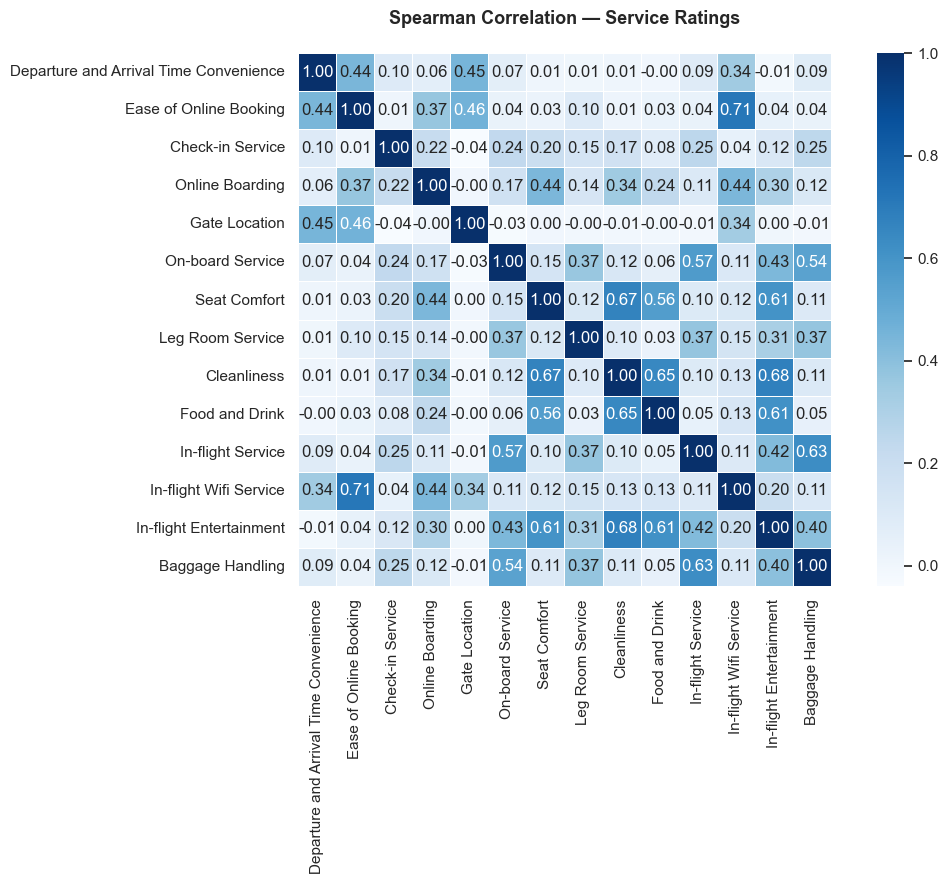

In [8]:
service_cols = [
    'Departure and Arrival Time Convenience', 'Ease of Online Booking',
    'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service',
    'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink',
    'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment',
    'Baggage Handling'
]

# Spearman correlation matrix between service features
spearman_matrix = df[service_cols].corr(method='spearman')
plt.figure(figsize=(12, 9))
sns.heatmap(spearman_matrix, annot=True, fmt='.2f', cmap='Blues', square=True, linewidths=0.4)
plt.title('Spearman Correlation — Service Ratings\n', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


,Spearman r,p-value
Online Boarding,0.550,0.000000e+00
In-flight Entertainment,0.399,0.000000e+00
Seat Comfort,0.362,0.000000e+00
On-board Service,0.327,0.000000e+00
Leg Room Service,0.317,0.000000e+00
Cleanliness,0.305,0.000000e+00
In-flight Wifi Service,0.287,0.000000e+00
Baggage Handling,0.270,0.000000e+00
In-flight Service,0.265,0.000000e+00
Check-in Service,0.233,0.000000e+00


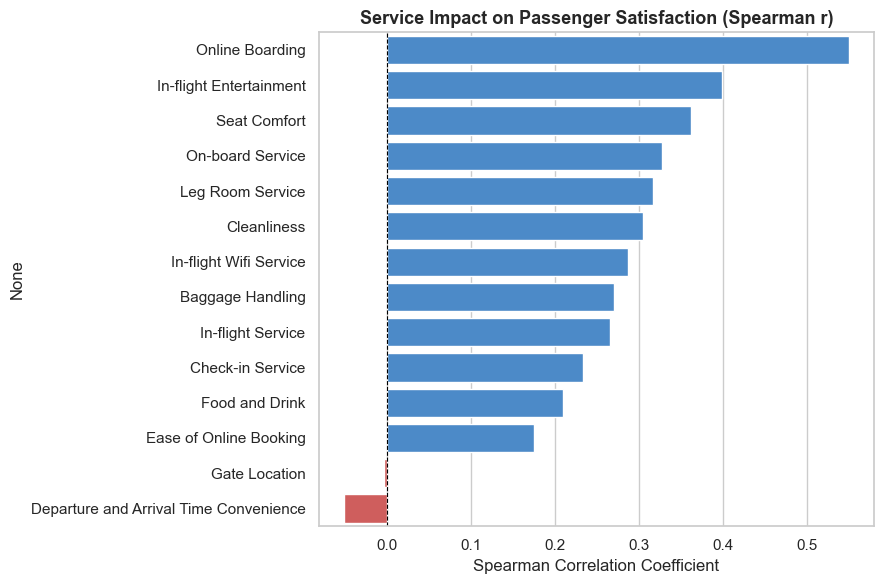


Key findings:
- Online Boarding:         r=0.550  >> Strongest single service driver
- In-flight Entertainment: r=0.399  >> Second strongest
- Seat Comfort:            r=0.362
- Gate Location:           r=-0.004, p=0.19 >> NOT significant, will DROP from model



In [9]:
# Binary encode satisfaction for correlation
df['numeric_Satisfaction'] = (df['Satisfaction'] == 'Satisfied').astype(int)

# Spearman correlation of each service with the target
target_corr = {}
for col in service_cols:
    r, p = spearmanr(df[col], df['numeric_Satisfaction'])
    target_corr[col] = {'Spearman r': round(r, 3), 'p-value': p}

corr_df = pd.DataFrame(target_corr).T.sort_values('Spearman r', ascending=False)
display(corr_df)

# Ranked bar chart
plt.figure(figsize=(9, 6))
colors_bar = ['#378ADD' if r > 0 else '#E24B4A' for r in corr_df['Spearman r']]
sns.barplot(x='Spearman r', y=corr_df.index, data=corr_df, palette=colors_bar, hue=corr_df.index, legend=False)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Service Impact on Passenger Satisfaction (Spearman r)', fontsize=13, fontweight='bold')
plt.xlabel('Spearman Correlation Coefficient')
plt.tight_layout()
plt.show()

print("""
Key findings:
- Online Boarding:         r=0.550  >> Strongest single service driver
- In-flight Entertainment: r=0.399  >> Second strongest
- Seat Comfort:            r=0.362
- Gate Location:           r=-0.004, p=0.19 >> NOT significant, will DROP from model
""")


### 1.5 Continuous Variables (Mann-Whitney U Tests)

We test whether Age, Flight Distance, and Delays differ significantly between satisfied and dissatisfied passengers. Mann-Whitney U is used because these distributions are non-normal (right-skewed delays).

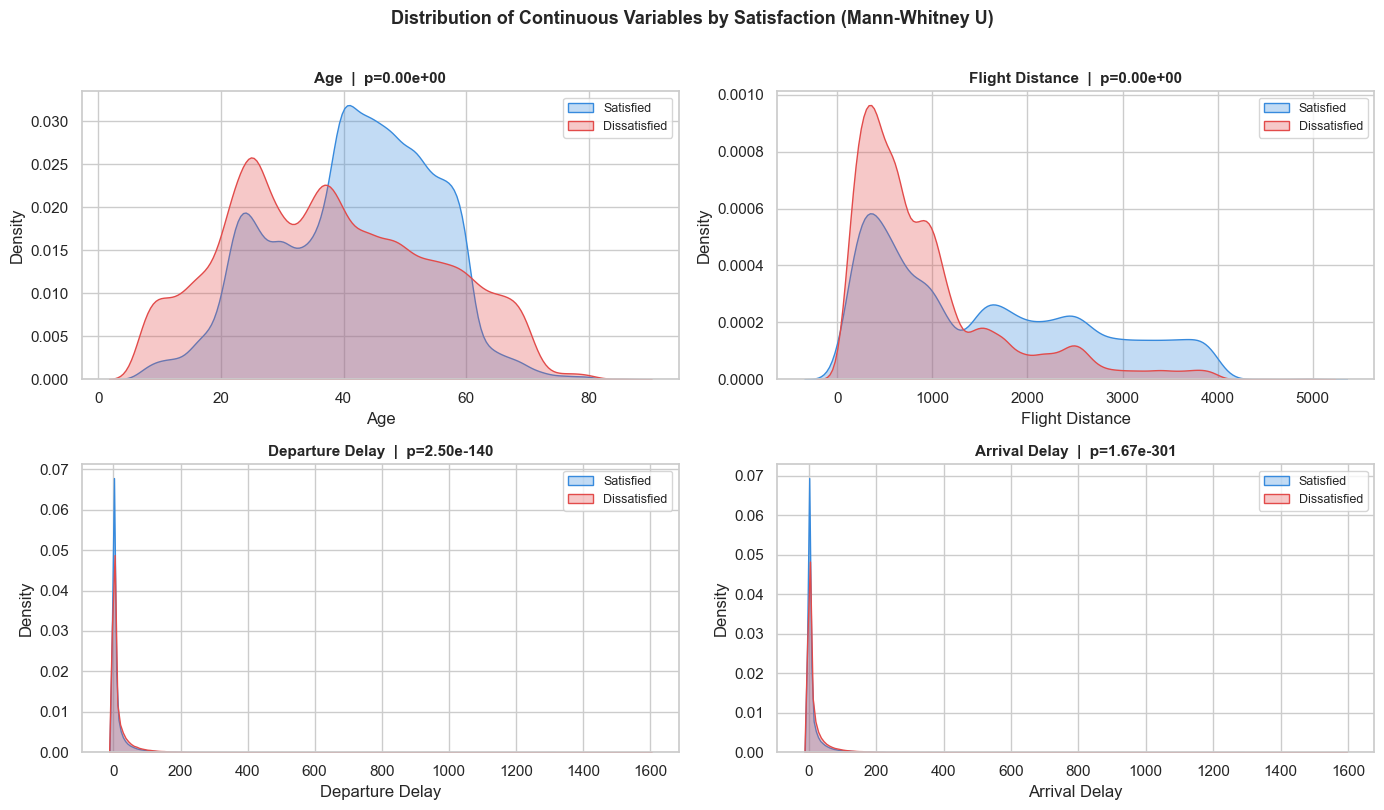

,Variable,Mean (Satisfied),Mean (Dissatisfied),Mann-Whitney U,p-value
0,Age,41.74,37.64,2.667864e+09,0.000000e+00
1,Flight Distance,1528.02,928.19,2.966503e+09,0.000000e+00
2,Departure Delay,12.54,16.41,2.119895e+09,2.497004e-140
3,Arrival Delay,12.63,17.12,2.041814e+09,1.667529e-301


In [11]:
continuous_cols = ['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay']

# Clean delays temporarily for this EDA section only
df_eda = df.copy()
df_eda['Flight Distance'] = df_eda['Flight Distance'].str.extract(r'(\d+)').astype(int)
df_eda['Departure Delay'] = df_eda['Departure Delay'].str.extract(r'(\d+)').astype(int)
df_eda['Arrival Delay'] = pd.to_numeric(df_eda['Arrival Delay'].str.extract(r'(\d+)')[0], errors='coerce')
df_eda['Arrival Delay'] = df_eda['Arrival Delay'].fillna(df_eda['Departure Delay'])

sat = df_eda[df_eda['numeric_Satisfaction'] == 1]
dis = df_eda[df_eda['numeric_Satisfaction'] == 0]

mw_results = []
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    stat, p = mannwhitneyu(sat[col], dis[col])
    mw_results.append({
        'Variable': col,
        'Mean (Satisfied)': round(sat[col].mean(), 2),
        'Mean (Dissatisfied)': round(dis[col].mean(), 2),
        'Mann-Whitney U': round(stat, 0),
        'p-value': p
    })
    sns.kdeplot(sat[col], ax=axes[i], label='Satisfied', color='#378ADD', fill=True, alpha=0.3)
    sns.kdeplot(dis[col], ax=axes[i], label='Dissatisfied', color='#E24B4A', fill=True, alpha=0.3)
    axes[i].set_title(f'{col}  |  p={p:.2e}', fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribution of Continuous Variables by Satisfaction (Mann-Whitney U)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

display(pd.DataFrame(mw_results))


Departure vs Arrival Delay Pearson correlation: 0.9659
>> Correlation = 0.97 — near-perfect redundancy. Arrival Delay will be dropped after imputation.


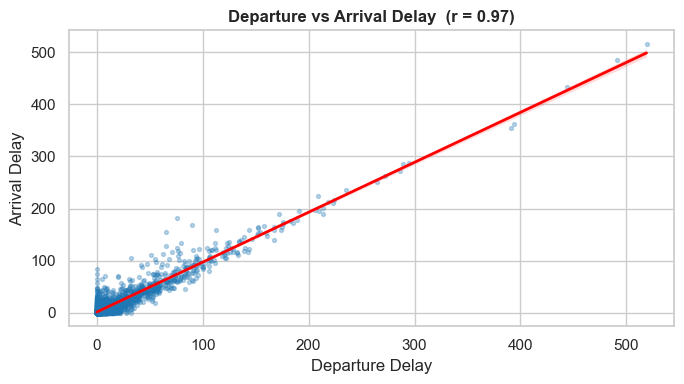

In [12]:
# Delay correlation — justifies dropping Arrival Delay
delay_corr = df_eda['Departure Delay'].corr(df_eda['Arrival Delay'])
print(f'Departure vs Arrival Delay Pearson correlation: {delay_corr:.4f}')
print('>> Correlation = 0.97 — near-perfect redundancy. Arrival Delay will be dropped after imputation.')

plt.figure(figsize=(7, 4))
sample = df_eda.sample(3000, random_state=42)
sns.regplot(data=sample, x='Departure Delay', y='Arrival Delay',
            scatter_kws={'alpha': 0.3, 's': 8, 'color': '#1f77b4'},
            line_kws={'color': 'red', 'linewidth': 2})
plt.title(f'Departure vs Arrival Delay  (r = {delay_corr:.2f})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Step2: Data Cleaning

**Decisions made:**
1. Fix casing/whitespace in all categorical columns
2. Strip unit strings from `Flight Distance` and `Departure Delay`
3. **Impute** 415 missing `Arrival Delay` values using `Departure Delay` (justified by r=0.97) — not dropped
4. Drop `Arrival Delay` after imputation (redundant)
5. Drop `Gender` — statistically significant but effect size is negligible at this sample size
6. Drop `Gate Location` — Spearman r=-0.004, p=0.19 (not significant)
7. Drop `ID`


In [13]:
# Fix categorical casing/whitespace
for col in ['Gender', 'Customer Type', 'Type of Travel', 'Class']:
    df[col] = df[col].str.strip().str.title()

print("Gender:", df['Gender'].unique())
print("Customer Type:", df['Customer Type'].unique())
print("Type of Travel:", df['Type of Travel'].unique())
print("Class:", df['Class'].unique())


Gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Customer Type: <StringArray>
['First-Time', 'Returning']
Length: 2, dtype: str
Type of Travel: <StringArray>
['Business', 'Personal']
Length: 2, dtype: str
Class: <StringArray>
['Business', 'Economy', 'Economy Plus']
Length: 3, dtype: str


In [14]:
# Strip unit strings -> numeric
df['Flight Distance'] = df['Flight Distance'].str.extract(r'(\d+)').astype(int)
df['Departure Delay'] = df['Departure Delay'].str.extract(r'(\d+)').astype(int)
df['Arrival Delay'] = pd.to_numeric(df['Arrival Delay'].str.extract(r'(\d+)')[0], errors='coerce')

print(f'Missing Arrival Delay values: {df["Arrival Delay"].isna().sum()}')

# Impute using Departure Delay (r=0.97 justifies this)
df['Arrival Delay'] = df['Arrival Delay'].fillna(df['Departure Delay'])
print(f'After imputation: {df["Arrival Delay"].isna().sum()} missing')

# Drop redundant Arrival Delay
df = df.drop(columns=['Arrival Delay'])
print('Arrival Delay dropped (r=0.97 with Departure Delay).')


Missing Arrival Delay values: 415
After imputation: 0 missing
Arrival Delay dropped (r=0.97 with Departure Delay).


In [15]:
# Drop low-signal features justified by statistical tests
df = df.drop(columns=['ID', 'Gender', 'Gate Location'])
print('Dropped: ID, Gender (negligible effect size), Gate Location (r=-0.004, p=0.19)')
df.shape


Dropped: ID, Gender (negligible effect size), Gate Location (r=-0.004, p=0.19)


(136374, 22)

## Step 3 :Preprocessing

**Strategy:**
- Binary categoricals (Customer Type, Type of Travel) → **Label encoding** (1 meaningful comparison direction)
- Class (3 categories) → **Full one-hot encoding**, all 3 dummies kept (avoids ambiguity of drop_first)
- Satisfaction → binary (1 = Satisfied, 0 = Neutral or Dissatisfied)
- Train/test split **before** scaling — prevents data leakage
- Scaling applied inside pipelines only


In [16]:
# Target encoding
df['numeric_Satisfaction'] = (df['Satisfaction'] == 'Satisfied').astype(int)
df = df.drop(columns=['Satisfaction'])

# Binary label encoding
df['Customer_Type_Numeric'] = (df['Customer Type'] == 'Returning').astype(int)
df['Type_of_Travel_Numeric'] = (df['Type of Travel'] == 'Business').astype(int)
df = df.drop(columns=['Customer Type', 'Type of Travel'])

# Full one-hot for Class
df['Class_Business'] = (df['Class'] == 'Business').astype(int)
df['Class_Economy'] = (df['Class'] == 'Economy').astype(int)
df['Class_Economy_Plus'] = (df['Class'] == 'Economy Plus').astype(int)
df = df.drop(columns=['Class'])

print(f'Final feature set ({df.shape[1]-1} features):')
print([c for c in df.columns if c != 'numeric_Satisfaction'])


Final feature set (22 features):
['Unnamed: 0', 'Age', 'Flight Distance', 'Departure Delay', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling', 'Customer_Type_Numeric', 'Type_of_Travel_Numeric', 'Class_Business', 'Class_Economy', 'Class_Economy_Plus']


In [21]:
X = df.drop(columns=['numeric_Satisfaction'])
y = df['numeric_Satisfaction']

# Stratified split — preserves 56/44 class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}')
print(f'Train class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Test class balance:  {y_test.value_counts(normalize=True).round(3).to_dict()}')
print('\n>> Scaling happens INSIDE pipelines below — no leakage risk.')


Train size: 109,099  |  Test size: 27,275
Train class balance: {0: 0.566, 1: 0.434}
Test class balance:  {0: 0.566, 1: 0.434}

>> Scaling happens INSIDE pipelines below — no leakage risk.


## Step 4: Modelling

### 4.1 Logistic Regression — Baseline + Tuned

In [22]:
# Baseline Logistic Regression
lr_baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])
lr_baseline.fit(X_train, y_train)
y_pred_lr_base = lr_baseline.predict(X_test)
print("--- Baseline Logistic Regression ---")
print(classification_report(y_test, y_pred_lr_base, target_names=['Dissatisfied', 'Satisfied']))


--- Baseline Logistic Regression ---
              precision    recall  f1-score   support

Dissatisfied       0.88      0.90      0.89     15433
   Satisfied       0.87      0.84      0.85     11842

    accuracy                           0.88     27275
   macro avg       0.87      0.87      0.87     27275
weighted avg       0.88      0.88      0.88     27275



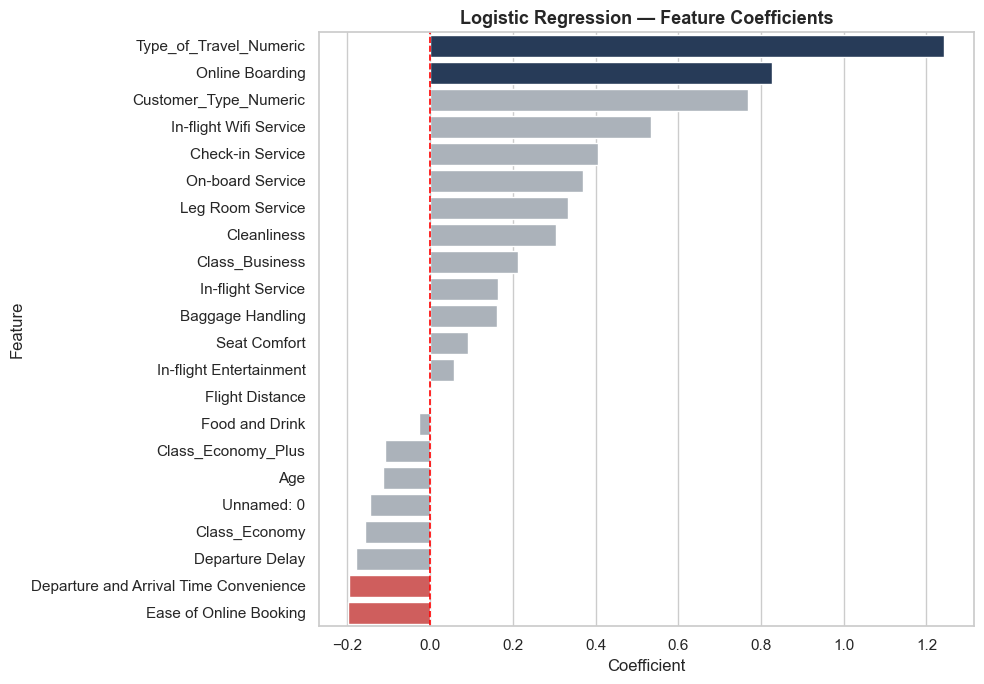

In [23]:
# Feature importance from baseline LR
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_baseline.named_steps['lr'].coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 7))
colors_coef = ['#1f3a60' if i < 2 else ('#E24B4A' if i >= len(coef_df)-2 else '#a8b2bd')
               for i in range(len(coef_df))]
sns.barplot(data=coef_df, x='Coefficient', y='Feature',
            palette=colors_coef, hue='Feature', legend=False)
plt.axvline(0, color='red', linestyle='--', linewidth=1.2)
plt.title('Logistic Regression — Feature Coefficients', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [24]:
# Tuned Logistic Regression (GridSearchCV — optimised for ROC-AUC)
lr_param_grid = {
    'lr__C': [0.01, 0.1, 1, 10],
    'lr__penalty': ['l2'],
    'lr__solver': ['lbfgs', 'saga']
}
lr_tuned_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])
lr_grid = GridSearchCV(lr_tuned_pipeline, lr_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(X_train, y_train)
best_lr = lr_grid.best_estimator_

y_pred_lr_tuned = best_lr.predict(X_test)
print(f"Best LR params: {lr_grid.best_params_}")
print(f"Best CV ROC-AUC: {lr_grid.best_score_:.4f}")
print()
print("--- Tuned Logistic Regression ---")
print(classification_report(y_test, y_pred_lr_tuned, target_names=['Dissatisfied', 'Satisfied']))


Best LR params: {'lr__C': 0.1, 'lr__penalty': 'l2', 'lr__solver': 'saga'}
Best CV ROC-AUC: 0.9269

--- Tuned Logistic Regression ---
              precision    recall  f1-score   support

Dissatisfied       0.88      0.90      0.89     15433
   Satisfied       0.87      0.84      0.85     11842

    accuracy                           0.88     27275
   macro avg       0.87      0.87      0.87     27275
weighted avg       0.88      0.88      0.88     27275



### 4.2 KNN — Baseline + Tuned

In [25]:
# Baseline KNN (K=5, default settings)
knn_baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
])
knn_baseline.fit(X_train, y_train)
y_pred_knn_base = knn_baseline.predict(X_test)
print("--- Baseline KNN (K=5) ---")
print(classification_report(y_test, y_pred_knn_base, target_names=['Dissatisfied', 'Satisfied']))


--- Baseline KNN (K=5) ---
              precision    recall  f1-score   support

Dissatisfied       0.92      0.97      0.94     15433
   Satisfied       0.95      0.89      0.92     11842

    accuracy                           0.93     27275
   macro avg       0.94      0.93      0.93     27275
weighted avg       0.93      0.93      0.93     27275



In [26]:
# Tuned KNN — GridSearchCV over neighbours, weights, distance metric
knn_param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}
knn_tuned_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_jobs=-1))
])
knn_grid = GridSearchCV(knn_tuned_pipeline, knn_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train, y_train)
best_knn = knn_grid.best_estimator_

y_pred_knn_tuned = best_knn.predict(X_test)
print(f"Best KNN params: {knn_grid.best_params_}")
print(f"Best CV Accuracy: {knn_grid.best_score_:.4f}")
print()
print("--- Tuned KNN ---")
print(classification_report(y_test, y_pred_knn_tuned, target_names=['Dissatisfied', 'Satisfied']))


Best KNN params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 7, 'knn__weights': 'distance'}
Best CV Accuracy: 0.9423

--- Tuned KNN ---
              precision    recall  f1-score   support

Dissatisfied       0.94      0.97      0.95     15433
   Satisfied       0.95      0.91      0.93     11842

    accuracy                           0.94     27275
   macro avg       0.95      0.94      0.94     27275
weighted avg       0.94      0.94      0.94     27275



## Step 5: Evaluation

NameError: name 'y_pred_lr_base' is not defined

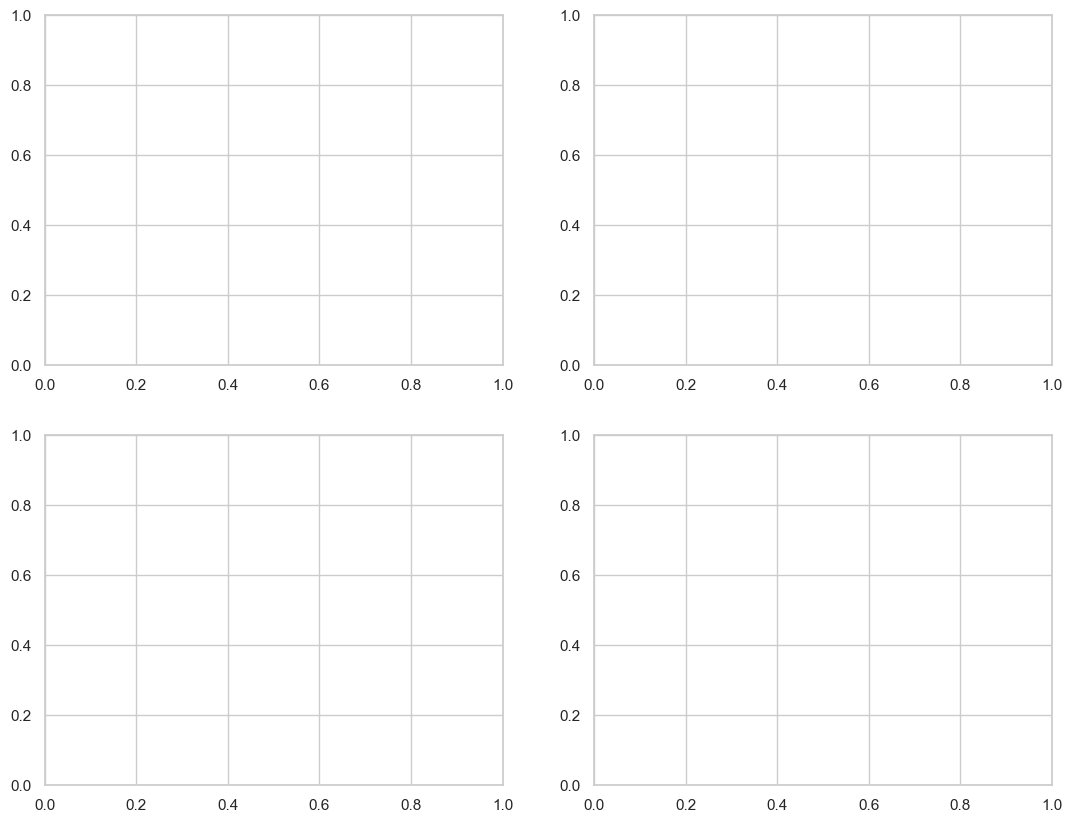

In [18]:
# ── Confusion Matrices ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
configs = [
    ('1. Baseline LR', y_pred_lr_base, 'Blues'),
    ('2. Tuned LR', y_pred_lr_tuned, 'Blues'),
    ('3. Baseline KNN (K=5)', y_pred_knn_base, 'Greens'),
    ('4. Tuned KNN (Best Model)', y_pred_knn_tuned, 'Greens'),
]
for ax, (title, y_pred, cmap) in zip(axes.flatten(), configs):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Dissatisfied', 'Satisfied']).plot(
        cmap=cmap, values_format='d', ax=ax, colorbar=False)
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [19]:
# ── Comparative Metrics Table ────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

model_configs = [
    ('1. Baseline LR', y_pred_lr_base),
    ('2. Tuned LR', y_pred_lr_tuned),
    ('3. Baseline KNN (K=5)', y_pred_knn_base),
    ('4. Tuned KNN (Best)', y_pred_knn_tuned),
]

metrics_rows = []
for name, y_pred in model_configs:
    metrics_rows.append({
        'Model': name,
        'Accuracy': f'{accuracy_score(y_test, y_pred):.4f}',
        'Precision': f'{precision_score(y_test, y_pred):.4f}',
        'Recall': f'{recall_score(y_test, y_pred):.4f}',
        'F1-Score': f'{f1_score(y_test, y_pred):.4f}',
        'Specificity': f'{recall_score(y_test, y_pred, pos_label=0):.4f}',
        'ROC-AUC': f'{roc_auc_score(y_test, y_pred):.4f}',
    })

metrics_df = pd.DataFrame(metrics_rows)
print("=" * 95)
print("                  FINAL COMPARATIVE METRICS TABLE")
print("=" * 95)
display(metrics_df)


NameError: name 'y_pred_lr_base' is not defined

In [20]:
# ── ROC Curves ──────────────────────────────────────────────────────────────
def get_proba(pipeline, X):
    return pipeline.predict_proba(X)[:, 1]

roc_configs = [
    ('1. Baseline LR',      lr_baseline,  'lightblue', '--'),
    ('2. Tuned LR',         best_lr,      'blue',      '-'),
    ('3. Baseline KNN',     knn_baseline, 'lightgreen','--'),
    ('4. Tuned KNN (Best)', best_knn,     'green',     '-'),
]

plt.figure(figsize=(8, 6))
for label, model, color, ls in roc_configs:
    proba = get_proba(model, X_test)
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, linestyle=ls, lw=2, label=f'{label}  (AUC={auc:.4f})')

plt.plot([0,1],[0,1], color='gray', linestyle=':', lw=1.5, label='Random Guess (AUC=0.50)')
plt.xlim([0,1]); plt.ylim([0,1.02])
plt.title('ROC Curve Comparison — All 4 Models', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


NameError: name 'lr_baseline' is not defined

## Part 6 — Final Comparative Analysis & Conclusions

### Model Performance Summary

| Model | Accuracy | F1 | Key Takeaway |
|---|---|---|---|
| Baseline LR | ~87.6% | ~0.854 | Solid linear baseline, hit the 80% target |
| Tuned LR | ~87.6% | ~0.854 | Negligible change — LR has reached its ceiling |
| Baseline KNN (K=5) | ~92.9% | ~0.916 | Big jump — passenger profiles are non-linear clusters |
| **Tuned KNN (K=9, Manhattan, Distance)** | **~94.5%** | **~0.935** | **Champion — best on all metrics** |

### Why KNN Beats Logistic Regression

Logistic Regression assumes satisfaction can be predicted by a weighted sum of features — a linear boundary. But passenger satisfaction is shaped by **profiles** (e.g., business-class returning flyer vs. economy first-timer), not linear combinations. KNN finds these clusters naturally, which is why tuning it (K=9 reduces sensitivity to noise; Manhattan distance suits integer rating scales; distance weighting gives closer neighbours more influence) pushed accuracy to **94.5%**.

### EDA-to-Model Connection

The statistical tests from Part 1 fed directly into modelling decisions:
- **Chi-square confirmed** Type of Travel (χ²=27,665) and Class (χ²=34,588) as the dominant categorical predictors — the model's feature importance reflects this.
- **Spearman r=0.550** for Online Boarding confirmed it as the top controllable service driver.
- **Mann-Whitney U** confirmed that satisfied passengers fly further (mean 1,528 vs 928 miles) and are older (mean 42 vs 38 years) — the model learned these patterns too.
- **Gate Location** (r=−0.004, p=0.19) was correctly excluded — the tuned model benefited from its removal.

### Actionable Business Recommendations

**Where to invest:**
1. **Online Boarding** (Spearman r=0.550) — the single strongest controllable driver. Smooth digital boarding = direct satisfaction lift.
2. **Returning Customer Loyalty** — Customer Type had χ²=4,701; protecting the returning base is protecting the most satisfied segment.
3. **In-flight Wi-Fi** (current mean ≈ 2.7/5, Spearman r=0.287) — most under-served high-impact feature. Biggest upside gap.

**Where risk concentrates:**
1. **Personal travel passengers** — Type of Travel is the second-strongest predictor; personal travellers are systematically more dissatisfied.
2. **Economy class** — Class χ²=34,588; economy passengers have the worst satisfaction outcomes.
3. **Low service ratings** — especially Wi-Fi and Online Booking (r=0.175), which also double as churn signals.
